In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import warnings
warnings.filterwarnings("ignore")

# Data Collection

In [2]:
Gold_price = pd.read_csv("Gold_price_2040.csv")
Gold_price

,Year,USD,EUR,GBP,INR,AED,CNY
0,2001,271,303,188,12789,996,2243
1,2002,310,328,206,15048,1137,2563
2,2003,363,321,222,16906,1334,3007
3,2004,409,329,223,18541,1503,3387
4,2005,444,358,245,19615,1632,3640
5,2006,604,480,328,27374,2218,4813
6,2007,695,507,347,28688,2554,5285
7,2008,872,593,472,37762,3203,6064
8,2009,972,697,621,47006,3571,6643
9,2010,1225,925,792,55974,4498,8283


# Data Understanding

In [9]:
Gold_price.shape

(24, 7)

In [3]:
Gold_price.isna().sum()

Year    0
USD     0
EUR     0
GBP     0
INR     0
AED     0
CNY     0
dtype: int64

In [4]:
Gold_price.dtypes

Year    int64
USD     int64
EUR     int64
GBP     int64
INR     int64
AED     int64
CNY     int64
dtype: object

In [6]:
Gold_price.drop_duplicates()

,Year,USD,EUR,GBP,INR,AED,CNY
0,2001,271,303,188,12789,996,2243
1,2002,310,328,206,15048,1137,2563
2,2003,363,321,222,16906,1334,3007
3,2004,409,329,223,18541,1503,3387
4,2005,444,358,245,19615,1632,3640
5,2006,604,480,328,27374,2218,4813
6,2007,695,507,347,28688,2554,5285
7,2008,872,593,472,37762,3203,6064
8,2009,972,697,621,47006,3571,6643
9,2010,1225,925,792,55974,4498,8283


In [7]:
Gold_price.describe()

,Year,USD,EUR,GBP,INR,AED,CNY
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,2012.500000,1147.125000,967.625000,802.041667,71962.333333,4201.958333,7774.541667
std,7.071068,538.476459,489.046527,447.869302,44873.493405,1961.587478,3347.554318
min,2001.000000,271.000000,303.000000,188.000000,12789.000000,996.000000,2243.000000
25%,2006.750000,672.250000,500.250000,342.250000,28359.500000,2470.000000,5167.000000
50%,2012.500000,1254.000000,1054.500000,848.000000,75771.500000,4605.500000,8294.500000
75%,2018.250000,1596.250000,1258.250000,1063.000000,91316.750000,5861.500000,10243.750000
max,2024.000000,1900.000000,1800.000000,1550.000000,150000.000000,6800.000000,13000.000000


# Check Assumptions

### Test-1 ----> Linearity test ,  Use lmplot or scatterplot

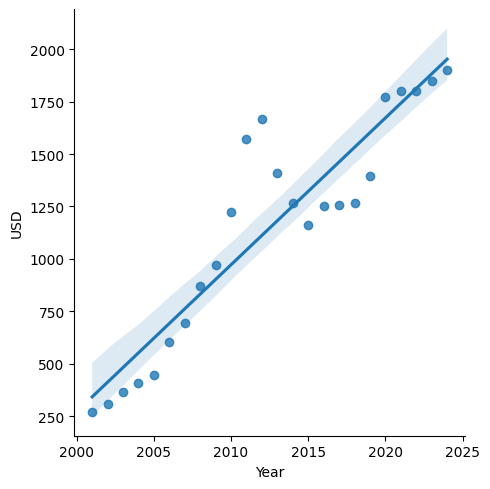

In [10]:
sns.lmplot(x="Year",y="USD",data=Gold_price)
plt.show()

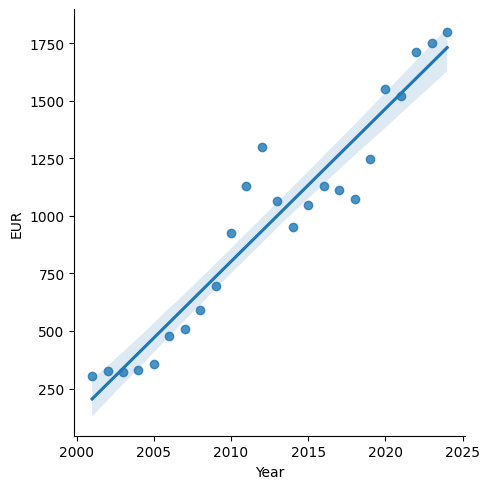

In [11]:
sns.lmplot(x="Year",y="EUR",data=Gold_price)
plt.show()

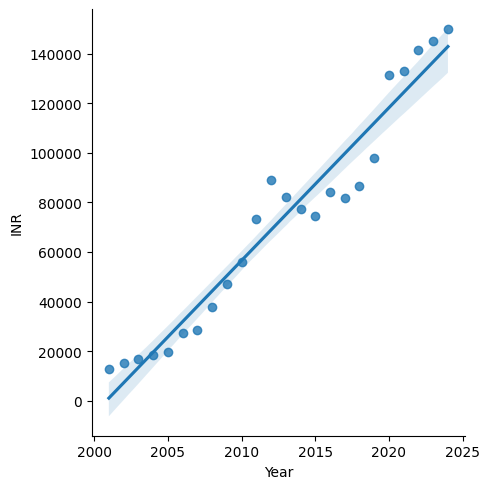

In [12]:
sns.lmplot(x="Year",y="INR",data=Gold_price)
plt.show()

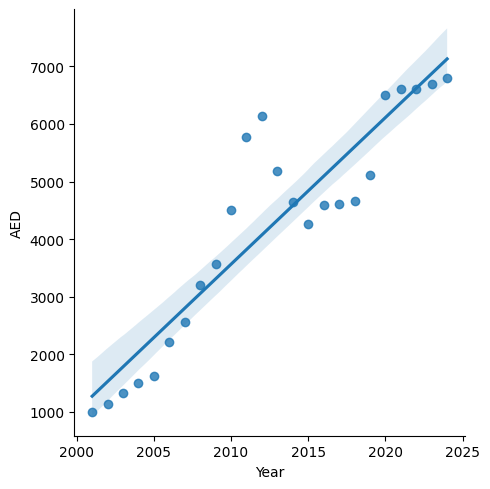

In [13]:
sns.lmplot(x="Year",y="AED",data=Gold_price)
plt.show()

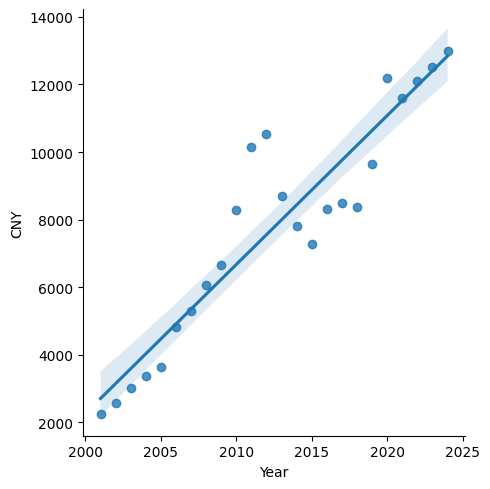

In [14]:
sns.lmplot(x="Year",y="CNY",data=Gold_price)
plt.show()

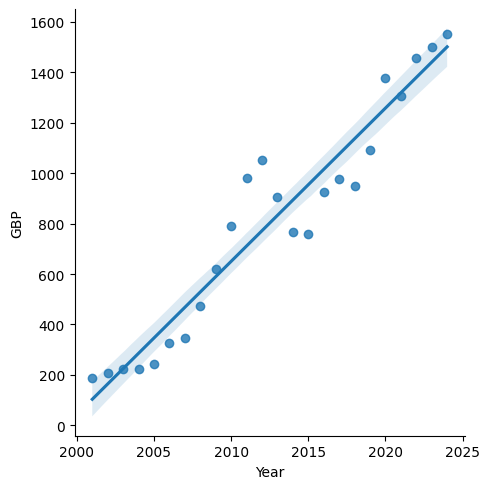

In [15]:
sns.lmplot(x="Year",y="GBP",data=Gold_price)
plt.show()

### Test-2 ---> Normality test , use distplot or histogram

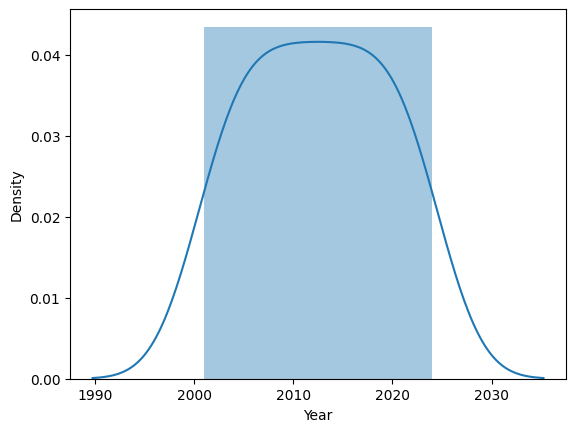

In [18]:
sns.distplot(Gold_price['Year'])
plt.show()

### Test-3 ---> Multicollinearity Test 

In [23]:
corr=Gold_price.corr()
corr

,Year,USD,EUR,GBP,INR,AED,CNY
Year,1.000000,0.919824,0.958957,0.959136,0.971255,0.917772,0.930519
USD,0.919824,1.000000,0.975621,0.976607,0.954937,0.999822,0.994060
EUR,0.958957,0.975621,1.000000,0.996320,0.991102,0.973424,0.982487
GBP,0.959136,0.976607,0.996320,1.000000,0.989146,0.974627,0.985762
INR,0.971255,0.954937,0.991102,0.989146,1.000000,0.952389,0.964982
AED,0.917772,0.999822,0.973424,0.974627,0.952389,1.000000,0.992954
CNY,0.930519,0.994060,0.982487,0.985762,0.964982,0.992954,1.000000


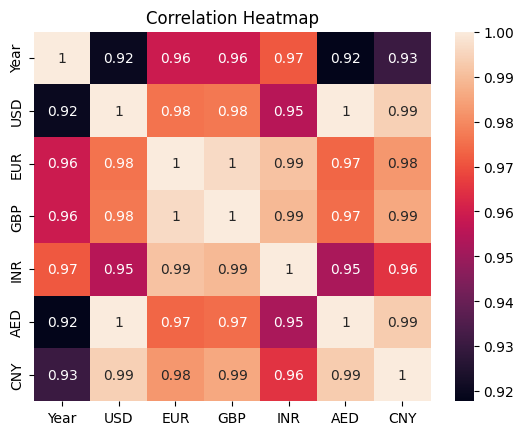

In [24]:
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Test-4 ---> AutoRegression  ,Time based columns donot use

# Train test split

In [36]:
X=Gold_price[["Year"]]
X

,Year
0,2001
1,2002
2,2003
3,2004
4,2005
5,2006
6,2007
7,2008
8,2009
9,2010


In [37]:
Y=Gold_price.drop("Year", axis=1)
Y

,USD,EUR,GBP,INR,AED,CNY
0,271,303,188,12789,996,2243
1,310,328,206,15048,1137,2563
2,363,321,222,16906,1334,3007
3,409,329,223,18541,1503,3387
4,444,358,245,19615,1632,3640
5,604,480,328,27374,2218,4813
6,695,507,347,28688,2554,5285
7,872,593,472,37762,3203,6064
8,972,697,621,47006,3571,6643
9,1225,925,792,55974,4498,8283


# Model Building

In [38]:
linear_model = LinearRegression()

# Model Training

In [39]:
linear_model.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
linear_model.intercept_

array([  -139821.5       ,   -132507.5       ,   -121457.33333333,
       -12332392.91666667,   -508179.66666667,   -878776.33333333])

In [43]:
linear_model.coef_

array([[  70.04652174],
       [  66.32304348],
       [  60.75      ],
       [6163.65478261],
       [ 254.59956522],
       [ 440.52217391]])

# Model Testing

In [46]:
y_pred=linear_model.predict(X)

# Model Evaluation

In [47]:
error = Y-y_pred

In [48]:
error

,USD,EUR,GBP,INR,AED,CNY
0,-70.590000,98.090000,84.583333,11708.696667,-278.063333,-465.536667
1,-101.636522,56.766957,41.833333,7804.041884,-391.662899,-586.058841
2,-118.683043,-16.556087,-2.916667,3498.387101,-449.262464,-582.581014
3,-142.729565,-74.879130,-62.666667,-1030.267681,-534.862029,-643.103188
4,-177.776087,-112.202174,-101.416667,-6119.922464,-660.461594,-830.625362
5,-87.822609,-56.525217,-79.166667,-4524.577246,-329.061159,-98.147536
6,-66.869130,-95.848261,-120.916667,-9374.232029,-247.660725,-66.669710
7,40.084348,-76.171304,-56.666667,-6463.886812,146.739710,271.808116
8,70.037826,-38.494348,31.583333,-3383.541594,260.140145,410.285942
9,252.991304,123.182609,141.833333,-579.196377,932.540580,1609.763768


### Test-5 -->Homoscadasticity 

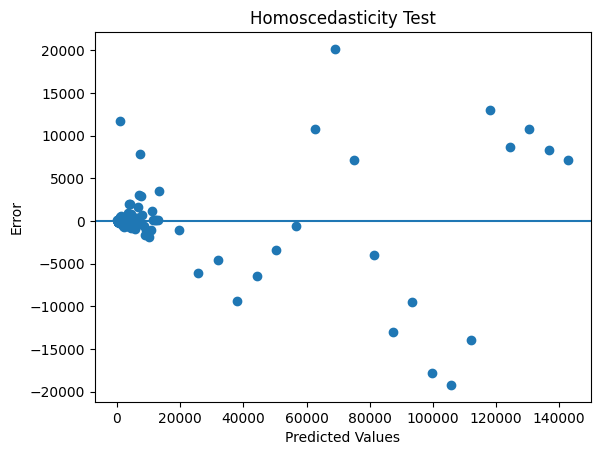

In [59]:
plt.scatter(y_pred,error)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Error")
plt.title("Homoscedasticity Test")
plt.show()

### Test-6 --> ZeroResidual Test

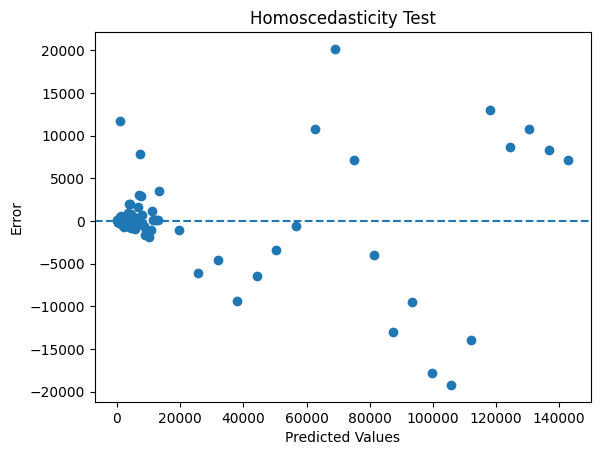

In [60]:
plt.scatter(y_pred,error)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Error")
plt.title("Homoscedasticity Test")
plt.show()

In [63]:
# evaluation metrics

mae = mean_absolute_error(Y,y_pred)
mse = mean_squared_error(Y,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y,y_pred)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 1818.298709742352
MSE: 18573813.66713086
RMSE: 4309.734756006553
R2: 0.8895208441271292


# Deployment

In [64]:
import pickle

# save the trained model
with open("gold_model.pkl", "wb") as file:
    pickle.dump(linear_model, file)

In [65]:
with open("gold_model.pkl", "rb") as file:
    model = pickle.load(file)

In [69]:
year = np.array([[2090]])
prediction = model.predict(year)
print("Predicted Gold Price:",prediction)

Predicted Gold Price: [[  6575.73043478   6107.66086957   5510.16666667 549645.57898551
   23933.42463768  41915.01014493]]
